In [17]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI

import operator
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
GEMINI_KEY = os.getenv('GEMINI_API_KEY')

In [ ]:
# State
class UPSEEssayEvaluation(TypedDict):
    essay: str
    clarity_of_thought: str
    depth_of_analysis: str
    lenguage_vocabulary: str

    cot_score: int
    doa_score: int
    lv_score: int
    average_score: float
    summary: str

# Structured Schema
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Constructive feedback explaining the strengths, weaknesses and specific areas for improvement in the evaluated criterion.")
    score: int = Field(description="A score from 1 to 10 representing the quality of the evaluated criterion, where 1 is very poor and 10 is excellent.", ge=1, le=10)


In [26]:
llm = ChatGoogleGenerativeAI(api_key=GEMINI_KEY, model="gemini-2.5-flash")
structured_llm = llm.with_structured_output(EvaluationSchema)


### Essays [`good_essay`, `bad_essay`]

In [27]:
good_essay = """
# Technology as a Catalyst for Inclusive and Sustainable Development

## Introduction

The trajectory of human civilization has been profoundly shaped by technological innovation. From the Industrial Revolution to the contemporary digital age, technology has consistently redefined the contours of economic growth, social progress, and governance. In the twenty-first century, technology has transcended its traditional role as a mere instrument of convenience and emerged as a transformative force capable of accelerating inclusive and sustainable development. For a nation as diverse and populous as India, technological advancement offers immense opportunities to bridge developmental disparities, enhance state capacity, and empower citizens. However, the true developmental potential of technology can be realized only when its benefits are distributed equitably and its challenges are addressed prudently.

## Technology as an Engine of Economic Transformation

Technology serves as a powerful driver of productivity, innovation, and economic competitiveness. Digital platforms have revolutionized the manner in which businesses operate, enabling enterprises to access wider markets and optimize operational efficiency. The proliferation of fintech solutions, digital payment systems, and e-commerce platforms has facilitated financial inclusion and expanded economic participation among previously underserved populations.

Furthermore, emerging technologies such as artificial intelligence, machine learning, robotics, and data analytics are fostering new avenues of entrepreneurship and employment generation. By reducing transaction costs, enhancing efficiency, and stimulating innovation, technology contributes significantly to economic modernization and long-term prosperity. In an increasingly interconnected global economy, technological capability has become a critical determinant of national competitiveness.

## Strengthening Governance and Public Service Delivery

The integration of technology into governance has substantially improved administrative efficiency, transparency, and accountability. Digital governance platforms have streamlined public service delivery by minimizing bureaucratic bottlenecks and reducing opportunities for corruption. Citizens can now access a wide range of government services through digital interfaces, thereby enhancing convenience and reducing administrative friction.

Moreover, technological tools enable evidence-based policymaking through the collection and analysis of real-time data. Advanced technologies such as Geographic Information Systems (GIS), remote sensing, and predictive analytics assist governments in urban planning, disaster management, resource allocation, and infrastructure development. Consequently, technology enhances the responsiveness and effectiveness of public institutions, thereby strengthening democratic governance.

## Advancing Social Inclusion and Human Development

One of the most compelling dimensions of technology is its capacity to promote social inclusion. Digital learning platforms have democratized access to educational resources, allowing learners from geographically remote regions to benefit from quality instruction. Similarly, telemedicine and digital health initiatives have expanded healthcare accessibility, particularly in underserved areas where medical infrastructure remains inadequate.

Technology also empowers marginalized groups by reducing barriers to participation in economic and social life. Assistive technologies have significantly enhanced opportunities for persons with disabilities, while digital platforms have enabled greater financial and entrepreneurial inclusion among women and rural communities. In this sense, technology functions not merely as an economic asset but as a potent instrument of social empowerment.

## Challenges and Emerging Concerns

Despite its transformative potential, technology is not devoid of challenges. The rapid pace of automation has generated apprehensions regarding job displacement and workforce disruption, particularly among low-skilled workers. Simultaneously, concerns relating to data privacy, cybersecurity, and digital surveillance have assumed increasing significance in an era characterized by extensive data collection and algorithmic decision-making.

Another pressing concern is the persistence of the digital divide. Unequal access to digital infrastructure and technological literacy risks exacerbating existing socioeconomic inequalities. Furthermore, the deployment of artificial intelligence raises ethical questions regarding transparency, accountability, and algorithmic bias. If left unaddressed, these challenges may undermine the inclusive potential of technological progress.

## The Way Forward

Harnessing technology for inclusive development necessitates a comprehensive and forward-looking policy framework. Investments in digital infrastructure, affordable internet connectivity, and digital literacy must be prioritized to ensure universal access. Equally important is the need for continuous skill development and reskilling initiatives that equip citizens to thrive in an evolving technological landscape.

Governments, private enterprises, academic institutions, and civil society organizations must collaborate to foster innovation while safeguarding public interest. Robust data protection laws, ethical standards for artificial intelligence, and transparent regulatory mechanisms are essential to ensuring that technological advancement remains aligned with democratic values and human welfare.

## Conclusion

Technology represents one of the most consequential forces shaping contemporary society. Its capacity to stimulate economic growth, enhance governance, and promote social inclusion renders it indispensable to the pursuit of sustainable development. Nevertheless, technological progress should not be evaluated solely in terms of innovation or efficiency. Its true significance lies in its ability to expand human capabilities, reduce inequalities, and improve the quality of life for all citizens. Therefore, the challenge before policymakers is not merely to promote technological advancement but to ensure that such advancement remains inclusive, ethical, and people-centric.

"""

bad_essay = """
# Technology and Development

Technology is becoming more important in our daily life. Today people use technology for communication, education, business, healthcare, and many other things. It has changed the way people live and work. Every country is trying to use technology for development because it can help solve many problems and make life easier.

One of the biggest benefits of technology is communication. In the past, people had to wait for days or weeks to send messages. Now people can talk to anyone in a few seconds using mobile phones and the internet. Social media and messaging applications have connected people from different parts of the world. This has made communication faster and more convenient.

Technology is also helping in education. Students can attend online classes and watch educational videos. They can find information on the internet without going to a library. During the COVID-19 pandemic, many schools and colleges used online platforms for teaching. This helped students continue their studies from home. However, not all students have access to smartphones and the internet, which creates problems for many families.

In healthcare, technology has improved the quality of treatment. Hospitals use machines and computers to diagnose diseases. Doctors can also talk to patients through video calls. Technology helped many people during the pandemic by providing information and medical support. New medicines and vaccines are also developed with the help of technology.

Technology is useful in agriculture as well. Farmers can use machines to reduce hard work and increase production. Weather forecasts and mobile applications help farmers make better decisions. Technology can also help farmers learn new methods of farming and improve their income.

At the same time, technology has some negative effects. Many people spend too much time on mobile phones and social media. Cybercrime and online fraud are increasing. Some jobs may disappear because machines can do the work faster than humans. This can create unemployment for some workers. Technology can also increase inequality because not everyone has equal access to digital resources.

The government is taking many steps to increase the use of technology. Digital services, online payments, and internet connectivity have improved in recent years. However, there is still a need to provide better internet access in rural areas and improve digital education. People should also be taught how to use technology safely and responsibly.

In conclusion, technology plays an important role in development. It helps people in many areas such as communication, education, healthcare, and agriculture. At the same time, there are some challenges that need attention. If technology is used properly and made available to everyone, it can contribute greatly to the development of society and the country.

"""

### Prompts [`depth_of_analysis_evaluator`, `language_vocabulary_evaluator`, `clarity_and_coherence_evaluator`]

In [28]:
depth_of_analysis_evaluator = """
You are an experienced UPSC Mains Essay evaluator.

Evaluate the essay ONLY on its depth of analysis and critical thinking.

Consider:

* Depth of arguments and reasoning
* Ability to examine multiple dimensions of the topic
* Quality of insights and originality of thought
* Balance and nuance in discussion
* Use of examples, evidence, case studies, or real-world references
* Ability to move beyond surface-level observations

Do NOT evaluate grammar, vocabulary, writing style, or structure unless they directly affect the depth of analysis.

Assign a score from 1 to 10 and provide constructive feedback explaining:

* What aspects of the analysis are strong
* Where the discussion lacks depth
* Specific suggestions to improve critical thinking and argument quality

Return the response strictly according to the provided schema.
"""

language_vocabulary_evaluator = """
You are an experienced UPSC Mains Essay evaluator.

Evaluate the essay ONLY on language quality.

Consider:

* Grammar and correctness
* Vocabulary and word choice
* Sentence construction and variety
* Formal and academic writing style
* Precision and clarity of expression
* Readability and fluency

Do NOT evaluate the quality of arguments, depth of analysis, or essay structure.

Assign a score from 1 to 10 and provide constructive feedback explaining:

* Strengths in writing quality
* Language errors or weaknesses
* Specific suggestions to improve vocabulary, grammar, and expression

Return the response strictly according to the provided schema.
"""

clarity_and_coherence_evaluator = """
You are an experienced UPSC Mains Essay evaluator.

Evaluate the essay ONLY on clarity, coherence, and organization.

Consider:

* Logical flow of ideas
* Structure of the essay
* Paragraph organization
* Transitions between sections
* Clarity of arguments
* Ease of understanding for the reader
* Effectiveness of the introduction and conclusion

Do NOT evaluate grammar, vocabulary, or depth of analysis except where they affect clarity.

Assign a score from 1 to 10 and provide constructive feedback explaining:

* Strengths in organization and presentation
* Areas where the flow or structure can be improved
* Specific suggestions to make the essay clearer and more coherent

Return the response strictly according to the provided schema.
"""

essay: str
    clarity_of_thought: str
    depth_of_analysis: str
    lenguage_vocabulary: str

    cot_score: int
    doa_score: int
    lv_score: int

In [29]:
from requests.models import Response
def cot_feedback(state: UPSEEssayEvaluation) -> UPSEEssayEvaluation:
    essay = state['essay']
    responce: EvaluationSchema = structured_llm.invoke(f"{clarity_and_coherence_evaluator}\n\nESSAY\n{essay}")
    return {"clarity_of_thought": responce.feedback, "cot_score": responce.score}

def doa_feedback(state: UPSEEssayEvaluation) -> UPSEEssayEvaluation:
    essay = state['essay']
    responce: EvaluationSchema = structured_llm.invoke(f"{depth_of_analysis_evaluator}\n\nESSAY\n{essay}")
    return {"depth_of_analysis": responce.feedback, "doa_score": responce.score}

def lv_feedback(state: UPSEEssayEvaluation) -> UPSEEssayEvaluation:
    essay = state['essay']
    responce: EvaluationSchema = structured_llm.invoke(f"{language_vocabulary_evaluator}\n\nESSAY\n{essay}")
    return {"lenguage_vocabulary": responce.feedback, "lv_score": responce.score}

def summary(state: UPSEEssayEvaluation) -> UPSEEssayEvaluation:
    cot = state['clarity_of_thought']
    doa = state['depth_of_analysis']
    lv = state['lenguage_vocabulary']

    cot_score = state['cot_score']
    doa_score = state['doa_score']
    lv_score = state['lv_score']


    responce = llm.invoke(f"""
Give the overall summary of the essay bases on this seperate evaluations.
clarity_of_thought:
{cot}

depth_of_analysis:
{doa}

lenguage_vocabulary:
{lv}
"""
    )

    average_score = (cot_score + doa_score + lv_score) / 3

    return {"summary": responce, "average_score": average_score} 

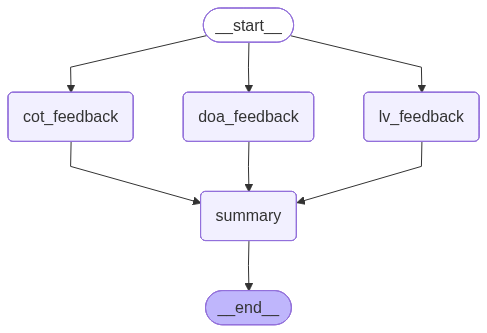

In [30]:
from langchain_core.runnables import graph_mermaid
graph = StateGraph(UPSEEssayEvaluation)

graph.add_node("cot_feedback", cot_feedback)
graph.add_node("doa_feedback", doa_feedback)
graph.add_node("lv_feedback", lv_feedback)
graph.add_node("summary", summary)



graph.add_edge(START, "cot_feedback")
graph.add_edge(START, "doa_feedback")
graph.add_edge(START, "lv_feedback")


graph.add_edge("cot_feedback", "summary")
graph.add_edge("doa_feedback", "summary")
graph.add_edge("lv_feedback", "summary")

graph.add_edge("summary", END)

workflow = graph.compile()
workflow


In [31]:
initial_state = {"essay": good_essay}
final_state = workflow.invoke(initial_state)
final_state

{'essay': '\n# Technology as a Catalyst for Inclusive and Sustainable Development\n\n## Introduction\n\nThe trajectory of human civilization has been profoundly shaped by technological innovation. From the Industrial Revolution to the contemporary digital age, technology has consistently redefined the contours of economic growth, social progress, and governance. In the twenty-first century, technology has transcended its traditional role as a mere instrument of convenience and emerged as a transformative force capable of accelerating inclusive and sustainable development. For a nation as diverse and populous as India, technological advancement offers immense opportunities to bridge developmental disparities, enhance state capacity, and empower citizens. However, the true developmental potential of technology can be realized only when its benefits are distributed equitably and its challenges are addressed prudently.\n\n## Technology as an Engine of Economic Transformation\n\nTechnology 

In [33]:
initial_state = {"essay": bad_essay}
final_state = workflow.invoke(initial_state)
final_state

{'essay': '\n# Technology and Development\n\nTechnology is becoming more important in our daily life. Today people use technology for communication, education, business, healthcare, and many other things. It has changed the way people live and work. Every country is trying to use technology for development because it can help solve many problems and make life easier.\n\nOne of the biggest benefits of technology is communication. In the past, people had to wait for days or weeks to send messages. Now people can talk to anyone in a few seconds using mobile phones and the internet. Social media and messaging applications have connected people from different parts of the world. This has made communication faster and more convenient.\n\nTechnology is also helping in education. Students can attend online classes and watch educational videos. They can find information on the internet without going to a library. During the COVID-19 pandemic, many schools and colleges used online platforms for 